## Evaluation Metrics Playbook

### Objective

The goal of this notebook is to understand how classification models should be evaluated in practical machine learning systems.

Rather than focusing on mathematical derivations, this notebook emphasizes:

- practical evaluation behavior
- business-oriented metric interpretation
- imbalanced classification challenges
- threshold-driven decision making
- probability reliability
- model failure analysis

The focus of this notebook is understanding practical evaluation behavior in real ML systems rather than mathematical derivations of metrics.

---

### Business Framing

We frame this problem as:

> Predicting whether a customer is likely to respond positively to a marketing campaign.

In this setting:

- False Positives may target uninterested customers, increasing marketing cost
- False Negatives may miss potential buyers and reduce conversions

This makes evaluation metrics important for business decision-making and campaign optimization

## Import Libraries

In [1]:
# Standard library
import random

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Local modules
from ml_playbook.config import DATA_DIR

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve
)
from sklearn.calibration import CalibrationDisplay

## Config

In [2]:
# Constants
RANDOM_STATE = 42
TARGET_COL = "Purchased"
TEST_SIZE = 0.25

# Paths
DATA_PATH = DATA_DIR / "Social_Network_Ads.csv"

# Reproducibility
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Load Dataset

In [3]:
df = pd.read_csv(DATA_PATH, header=0)
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Shape: (400, 3)

Data Types:
 Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object


**Dataset Overview**

We use the `Social_Network_Ads.csv` dataset containing:
- `Age` -> Customer age
- `EstimatedSalary` -> Estimated annual salary
- `Purchased` -> Whether the customer responded positively to the marketing campaign

This is a binary classification problem where the goal is to predict customer purchase behavior based on demographic information

In [4]:
# Preview
df.head(5)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [6]:
print(y.value_counts(normalize=True))

Purchased
0    0.6425
1    0.3575
Name: proportion, dtype: float64


**Observation**
- The dataset shows moderate class imbalance
- The positive class (`Purchased = 1`) represents the minority class
- In imbalanced settings, accuracy alone may not reflect true model performance
- Metrics like Precision, Recall, F1-score, and ROC-AUC become more informative

## Train/Test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=TEST_SIZE, 
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)

**Notes**
- Stratified splitting preserves the original class distribution across training and test datasets
- This is important in imbalanced classification problems because random splitting can accidentally distort minority-class representation

## Column typing

In [8]:
# All columns are numeric
numeric_features = X_train.columns.tolist()

## Preprocessing skeleton

In [9]:
# feature-scaling preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

## Train Logistic Regression Baseline Model

In [10]:
# pipeline with feature scaling
lr_baseline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])
lr_baseline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate Predictions and Probabilities

In [11]:
y_pred = lr_baseline.predict(X_test)
y_prob = lr_baseline.predict_proba(X_test)[:, 1]

In [12]:
# Metrics
lr_baseline_roc_auc = roc_auc_score(y_test, y_prob)
lr_baseline_accuracy = accuracy_score(y_test, y_pred)
lr_baseline_precision = precision_score(y_test, y_pred)
lr_baseline_recall = recall_score(y_test, y_pred)
lr_baseline_f1 = f1_score(y_test, y_pred)

# Confusion matrix
lr_baseline_cm = confusion_matrix(y_test, y_pred)

In [13]:
# Print metrics
print("=== Logistic Regression Baseline Metrics ===\n")

print(f"ROC-AUC  : {lr_baseline_roc_auc:.4f}")
print(f"Accuracy : {lr_baseline_accuracy:.4f}")
print(f"Precision: {lr_baseline_precision:.4f}")
print(f"Recall   : {lr_baseline_recall:.4f}")
print(f"F1-Score : {lr_baseline_f1:.4f}")

=== Logistic Regression Baseline Metrics ===

ROC-AUC  : 0.9102
Accuracy : 0.8400
Precision: 0.8571
Recall   : 0.6667
F1-Score : 0.7500


**Initial Evaluation Observations**
- The model achieves strong ROC-AUC performance, indicating good ranking capability between classes
- Precision is relatively high, meaning most customers predicted as likely buyers actually belong to the positive class
- Recall is lower than Precision, indicating the model still misses some potential buyers
- This creates an important business tradeoff:
    - improving Recall may identify more potential buyers
    - but may also increase marketing spend on uninterested customers
- Accuracy alone does not fully capture these tradeoffs

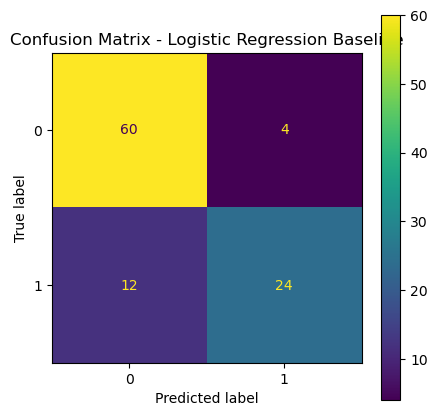

In [14]:
# Display confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay(
    confusion_matrix=lr_baseline_cm,
    display_labels=["0", "1"]
).plot(ax=ax)
ax.set_title("Confusion Matrix - Logistic Regression Baseline")

plt.show()

**Confusion Matrix Interpretation**
- True Negatives: Customers correctly identified as unlikely to purchase
- True Positives: Customers correctly identified as likely to purchase
- False Positives: Customers incorrectly targeted despite low purchase likelihood
- False Negatives: Potential buyers missed by the marketing campaign

In marketing systems, the acceptable balance between False Positives and False Negatives depends on campaign cost, customer reach, and conversion goals

**Confusion Matrix Insights**
- The model correctly identifies most non-buyers (`60` True Negatives)
- The model successfully identifies `24` potential buyers
- Only `4` uninterested customers are incorrectly targeted
- However, `12` potential buyers are still missed

This suggests the current model is relatively conservative in predicting positive outcomes:
- Precision remains high
- But some potential conversions are lost due to lower Recall

# ROC and Precision-Recall Curve Analysis

In the previous section, we evaluated the model using metrics computed at a single classification threshold. However, classification models produce probability scores, and model behavior can change significantly depending on the chosen threshold.

To better understand model performance across all possible thresholds, we use:

- ROC Curves
- Precision-Recall Curves

These curves help evaluate:

- ranking quality
- threshold behavior
- class separation capability
- positive prediction reliability

They are especially useful in imbalanced classification problems where Accuracy alone can become misleading.

## Why Threshold-Independent Evaluation Matters

Metrics like Precision, Recall, and F1-score depend on a specific classification threshold.

Changing the threshold changes:
- predicted labels
- confusion matrix values
- Precision
- Recall
- F1-score

ROC and Precision-Recall curves help evaluate model behavior across all possible thresholds rather than at only one operating point.

## ROC Curve Analysis

- ROC stands for Receiver Operating Characteristic
- ROC Curve plots:
    - True Positive Rate (Recall)
    - vs False Positive Rate
- Each point on the ROC curve represents a different classification threshold
- ROC-AUC measures how well the model ranks positive samples above negative samples across all classification thresholds

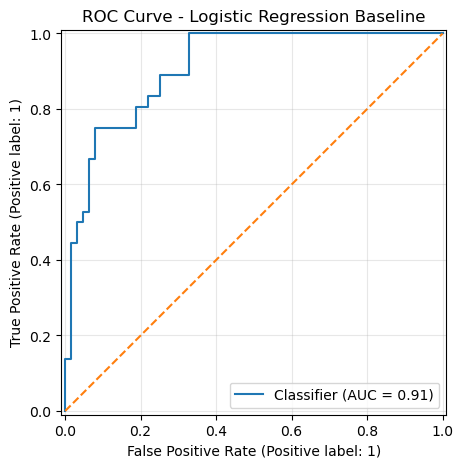

In [15]:
# Plot ROC Curve
fig, ax = plt.subplots(figsize=(5, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=ax
)
ax.set_title("ROC Curve - Logistic Regression Baseline")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.grid(alpha=0.3)

plt.show()

**ROC Curve Observations**
- The ROC curve stays significantly above the random baseline, indicating strong class separation capability
- The model achieves a ROC-AUC score of approximately `0.91`, suggesting strong ranking performance
- This means the model is generally effective at assigning higher probabilities to likely buyers than non-buyers
- ROC-AUC evaluates ranking quality across all possible classification thresholds rather than performance at a single operating threshold

## Precision-Recall Curve Analysis

- Precision-Recall curves evaluate model performance across different classification thresholds
- Precision measures how many predicted positives are actually positive
- Recall measures how many actual positives are correctly identified
- Each point on the curve represents a different classification threshold

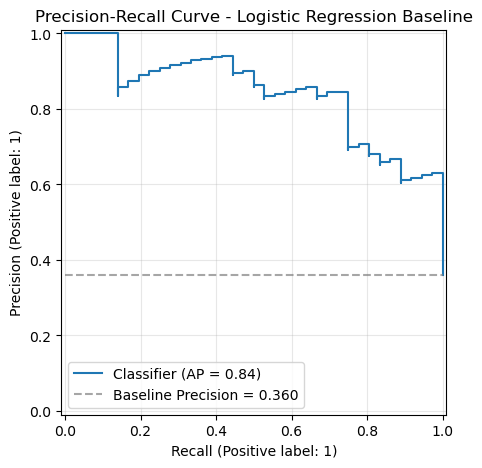

In [16]:
# Plot Precision-Recall Curve
fig, ax = plt.subplots(figsize=(5, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob,
    ax=ax
)

# Baseline precision
baseline_precision = y_test.mean()

ax.hlines(
    y=baseline_precision,
    xmin=0,
    xmax=1,
    linestyle="--",
    color="gray",
    alpha=0.7,
    label=f"Baseline Precision = {baseline_precision:.3f}"
)

ax.set_title("Precision-Recall Curve - Logistic Regression Baseline")
ax.grid(alpha=0.3)
ax.legend()

plt.show()

**Precision-Recall Curve Observations**
- The model maintains relatively high Precision across a wide range of Recall values
- As Recall increases, Precision gradually decreases, reflecting the tradeoff between identifying more buyers and increasing false positives
- The Average Precision (AP) score of approximately `0.84` indicates strong positive-class prediction performance
- Precision-Recall curves are especially informative for imbalanced classification problems because they focus directly on positive prediction quality

**Baseline Precision Insight**
- The horizontal dashed line represents baseline Precision, which equals the positive-class prevalence in the dataset
- A strong PR curve should stay meaningfully above this baseline across Recall values

**Important Insight**
- Precision-Recall curves focus more directly on the quality and usefulness of positive predictions
- In imbalanced datasets, PR curves often provide more practical insight into model behavior than ROC curves

## ROC-AUC vs PR-AUC

- ROC-AUC evaluates overall ranking quality between classes
- PR-AUC evaluates the quality and reliability of positive predictions
- ROC-AUC is threshold-independent and evaluates ranking behavior across all thresholds
- PR-AUC is more sensitive to False Positives and class imbalance

    | Metric Perspective | Focus |
    |---|---|
    | ROC-AUC | Overall ranking quality |
    | PR-AUC | Positive prediction usefulness |
    | Precision | Correctness of positive predictions |
    | Recall | Ability to capture actual positives |

**Business Interpretation**
- A model with strong ROC-AUC can separate buyers from non-buyers effectively overall
- However, if Precision is low, marketing campaigns may still waste resources targeting many uninterested customers
- PR-AUC helps evaluate whether positive predictions remain reliable as Recall increases
- This becomes especially important when the positive class is relatively rare

**Important Insight**
- A model can achieve strong ROC-AUC performance while still producing poor Precision or Recall at a specific threshold
- Final business performance depends not only on ranking quality, but also on threshold selection and acceptable error tradeoffs

## Key Takeaways

- ROC-AUC evaluates how well the model ranks positive samples above negative samples
- Precision-Recall curves focus more directly on the quality of positive predictions
- ROC-AUC is less sensitive to class imbalance because False Positive Rate is normalized by the large number of negative samples
- PR curves become more informative when the positive class is relatively rare because they focus directly on positive prediction quality
- Precision and Recall depend on the chosen operating threshold
- Strong ranking quality does not always guarantee strong classification performance at a fixed threshold
- Model evaluation should align with business objectives and acceptable error tradeoffs

# Threshold Tuning and Operating Point Analysis

## Why Threshold Selection Matters

Classification models produce probability scores, but final business decisions require converting those probabilities into class predictions.

By default, many classification models use:

- probability >= 0.5 → Positive class
- probability < 0.5 → Negative class

However, the choice of threshold significantly affects model behavior.

Changing the threshold changes:

- Precision
- Recall
- False Positives
- False Negatives
- overall business behavior

As the threshold changes, the same model can become:

- more conservative
- more aggressive
- more precision-oriented
- more recall-oriented

In practical ML systems, threshold selection is often guided by business objectives and acceptable error tradeoffs rather than by a fixed default value.

## Baseline Threshold Evaluation (Threshold = 0.5)

We begin by evaluating the model at the default operating threshold of `0.5`.

This serves as the baseline reference point before analyzing how model behavior changes across different thresholds.

In [17]:
# Print metrics
print("=== Baseline Threshold Evaluation (Threshold = 0.5) ===\n")

print(f"Precision: {lr_baseline_precision:.4f}")
print(f"Recall   : {lr_baseline_recall:.4f}")
print(f"F1-Score : {lr_baseline_f1:.4f}")

# Display confusion matrix
cm_df = pd.DataFrame(
    lr_baseline_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("\nConfusion Matrix:")
display(cm_df)

=== Baseline Threshold Evaluation (Threshold = 0.5) ===

Precision: 0.8571
Recall   : 0.6667
F1-Score : 0.7500

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,60,4
Actual 1,12,24


**Baseline Threshold Observations**
- The default threshold produces relatively high Precision, meaning most targeted customers are genuinely likely buyers
- Recall is comparatively lower, indicating that some potential buyers are still being missed
- The model currently behaves somewhat conservatively, prioritizing prediction correctness over capturing all possible buyers
- Lowering the threshold may improve Recall but could also increase False Positives and marketing cost

## Precision-Recall Tradeoff Across Thresholds

- Precision and Recall change continuously as the classification threshold changes
- Lower thresholds generally increase Recall but may reduce Precision
- Higher thresholds generally increase Precision but may reduce Recall
- Threshold selection controls how aggressively or conservatively the model predicts the positive class

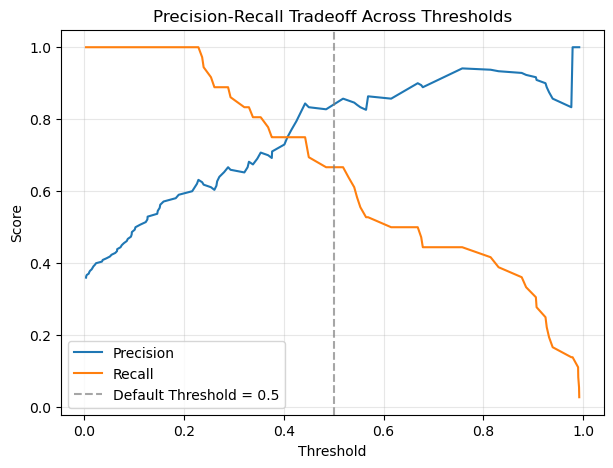

In [18]:
# Compute precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Plot Precision and Recall vs Threshold
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    thresholds,
    precision[:-1],
    label="Precision"
)

ax.plot(
    thresholds,
    recall[:-1],
    label="Recall"
)

# Default threshold reference
ax.axvline(
    x=0.5,
    linestyle="--",
    color="gray",
    alpha=0.7,
    label="Default Threshold = 0.5"
)

ax.set_title("Precision-Recall Tradeoff Across Thresholds")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

**Threshold Tradeoff Observations**
- At lower thresholds, the model predicts the positive class more aggressively, resulting in higher Recall
- However, lower thresholds also increase False Positives, reducing Precision
- As the threshold increases, the model becomes more conservative, improving Precision while reducing Recall
- Around the middle threshold range, Precision and Recall achieve a more balanced tradeoff
- The choice of threshold should depend on business priorities rather than a fixed default value

**Important Insight**
- The model itself does not change across thresholds
- Only the decision boundary changes
- Threshold tuning allows the same model to operate differently under different business requirements

## Threshold-wise Confusion Matrix Analysis

In [19]:
thresholds_to_evaluate = [0.3, 0.5, 0.7]

results = []

for threshold in thresholds_to_evaluate:

    # Generate predictions
    y_pred_threshold = (y_prob >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    # Metrics
    threshold_precision = precision_score(
        y_test,
        y_pred_threshold
    )

    threshold_recall = recall_score(
        y_test,
        y_pred_threshold
    )

    threshold_f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    # Store results
    results.append({
        "Threshold": threshold,
        "Precision": round(threshold_precision, 4),
        "Recall": round(threshold_recall, 4),
        "F1-Score": round(threshold_f1, 4),
        "Predicted Positives": tp + fp,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn     
    })

# Create dataframe
threshold_analysis_df = pd.DataFrame(results)

display(threshold_analysis_df)

,Threshold,Precision,Recall,F1-Score,Predicted Positives,TP,FP,TN,FN
0,0.3,0.6522,0.8333,0.7317,46,30,16,48,6
1,0.5,0.8571,0.6667,0.7500,28,24,4,60,12
2,0.7,0.9412,0.4444,0.6038,17,16,1,63,20


**Threshold-wise Confusion Matrix Observations**
- Lower thresholds increase positive predictions, improving Recall but also increasing False Positives
- Higher thresholds make the model more conservative, improving Precision while increasing False Negatives
- At threshold `0.3`, the model captures more potential buyers but significantly increases campaign targeting volume
- At threshold `0.7`, the model becomes highly selective, reducing unnecessary targeting but missing many potential buyers
- Threshold `0.5` achieves the highest F1-score among the evaluated thresholds, indicating a stronger overall balance between Precision and Recall

## Business Tradeoff Interpretation

Threshold selection directly affects how aggressively the business targets potential customers.

Lower thresholds:
- increase customer coverage
- improve Recall
- reduce missed opportunities
- but may increase unnecessary marketing spend due to more False Positives

Higher thresholds:
- improve Precision
- reduce unnecessary targeting
- lower campaign costs
- but may miss genuine potential buyers

This demonstrates that evaluation metrics are closely tied to operational and business decisions rather than being purely statistical measures.

## Choosing Thresholds Based on Business Objectives

There is no universally optimal classification threshold.

The best threshold depends on:
- business priorities
- acceptable error tradeoffs
- operational constraints
- campaign budget
- risk tolerance

Examples:

- If maximizing customer reach is important, a lower threshold may be preferred to improve Recall
- If reducing unnecessary marketing spend is more important, a higher threshold may be preferred to improve Precision

Threshold tuning allows the same model to operate differently under different business requirements without retraining the model itself.

## Key Takeaways

- Classification thresholds directly influence model behavior and business outcomes
- Threshold tuning controls how aggressively or conservatively a model predicts the positive class
- The same underlying model can produce very different operational and business outcomes depending on the selected classification threshold
- Threshold tuning helps align model behavior with business objectives and operational constraints
- Strong model performance depends not only on ranking quality, but also on selecting an appropriate operating threshold
- In real-world ML systems, threshold tuning is often revisited continuously as business objectives and operating conditions evolve

# Calibration Analysis and Probability Confidence Evaluation

In previous sections, we evaluated:
- classification performance
- ranking quality
- threshold behavior

However, many real-world ML systems rely heavily on predicted probabilities themselves. Examples include:
- customer conversion likelihood
- fraud risk estimation
- medical risk scoring
- credit default probability

In these systems, probability estimates should ideally reflect real-world likelihoods accurately. 

This concept is known as probability calibration.

A well-calibrated model produces probability estimates that closely reflect real-world outcome frequencies.

## Why Probability Calibration Matters

A model can achieve strong Accuracy or ROC-AUC performance while still producing poorly calibrated probabilities. For example:
- if a model predicts `0.80` probability for many customers,
- roughly 80% of those customers should actually belong to the positive class.

Calibration focuses on the reliability of predicted probabilities rather than only classification correctness.

This becomes especially important in systems where probabilities directly influence business decisions and resource allocation.

## Predicted Probabilities vs Actual Outcomes

In [20]:
probability_analysis_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Probability": y_prob
})

display(
    probability_analysis_df
    .sort_values(
        by="Predicted_Probability",
        ascending=False
    ).reset_index(drop=True).head(10)
)

,Actual,Predicted_Probability
0,1,0.992071
1,1,0.991647
2,1,0.990110
3,1,0.989750
4,1,0.978767
5,0,0.976199
6,1,0.938805
7,1,0.931556
8,1,0.926923
9,1,0.924442


**Probability Confidence Observations**
- Most high-probability predictions correspond to actual positive outcomes, indicating that the model generally assigns higher confidence to likely buyers
- However, some incorrect predictions still receive extremely high probability scores
- For example, one negative sample received a predicted probability above `0.97`, despite belonging to the negative class
- Predicted probabilities should therefore be interpreted as confidence estimates rather than guarantees of correctness

## Calibration Curve Analysis

- Calibration curves compare predicted probabilities with actual observed outcome frequencies
- A perfectly calibrated model should produce predicted probabilities that closely match observed outcome frequencies
- Predictions closer to the diagonal line indicate better probability calibration
- Deviations from the diagonal indicate overconfident or underconfident probability estimates

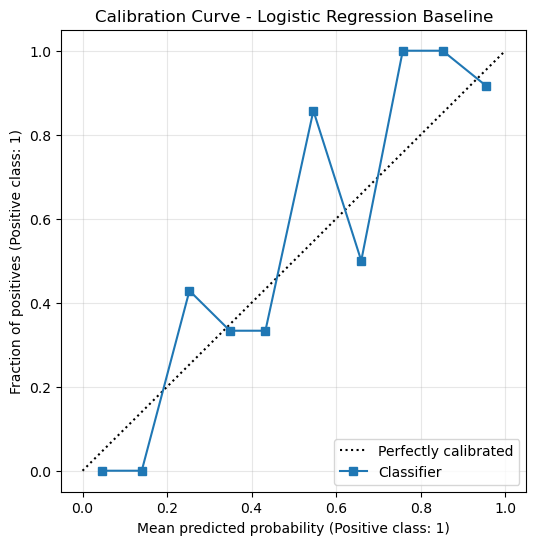

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))

CalibrationDisplay.from_predictions(
    y_test,
    y_prob,
    n_bins=10,
    ax=ax
)

ax.set_title("Calibration Curve - Logistic Regression Baseline")
ax.grid(alpha=0.3)

plt.show()

**Calibration Curve Observations**
- The calibration curve generally follows the diagonal trend, indicating reasonably calibrated probability estimates
- Some probability ranges deviate from the perfectly calibrated line, suggesting slight overconfidence or underconfidence in certain regions
- Higher predicted probabilities are generally associated with higher observed positive rates, indicating meaningful confidence estimation behavior
- The model demonstrates relatively reliable probability behavior overall, although calibration is not perfectly consistent across all probability ranges

**Important Insight**
- Strong Accuracy or ROC-AUC performance does not automatically guarantee well-calibrated probabilities
- Calibration evaluates whether predicted confidence levels realistically reflect actual outcome likelihoods
- Well-calibrated probabilities become especially important when probabilities directly influence business decisions and prioritization

## Confidence Distribution for Correct vs Incorrect Predictions

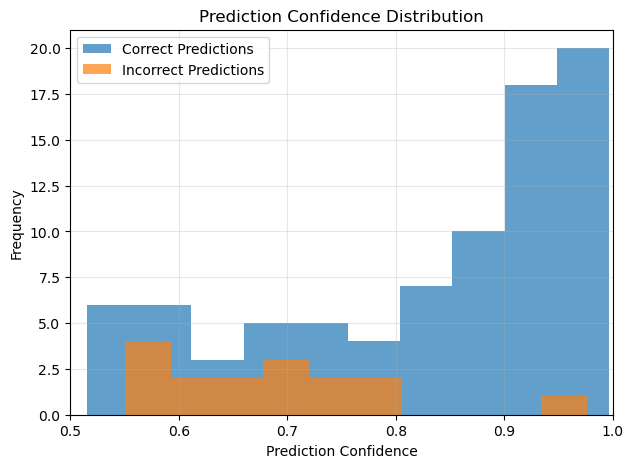

In [22]:
prediction_confidence = np.maximum(
    y_prob,
    1 - y_prob
)

correct_mask = y_pred == y_test

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    prediction_confidence[correct_mask],
    bins=10,
    alpha=0.7,
    label="Correct Predictions"
)

ax.hist(
    prediction_confidence[~correct_mask],
    bins=10,
    alpha=0.7,
    label="Incorrect Predictions"
)

ax.set_title("Prediction Confidence Distribution")
ax.set_xlabel("Prediction Confidence")
ax.set_ylabel("Frequency")

ax.set_xlim(0.5, 1.0)
ax.grid(alpha=0.3)
ax.legend()

plt.show()

**Confidence Distribution Observations**
- Incorrect predictions are more concentrated in lower confidence ranges, although some high-confidence errors still occur
- Correct predictions are more heavily concentrated in higher confidence ranges, indicating meaningful confidence estimation behavior
- Some incorrect predictions still occur at very high confidence levels, indicating occasional overconfident errors
- High-confidence mistakes can be especially risky in real-world systems because the model appears very certain while being incorrect

**Important Insight**
- Prediction confidence reflects how certain the model is about its decisions, not whether the prediction is guaranteed to be correct
- Confidence analysis helps evaluate the trustworthiness of model predictions beyond traditional classification metrics
- In practical ML systems, identifying high-confidence errors is often critical for risk management and decision reliability

## Overconfident vs Underconfident Models

Strong Accuracy or ROC-AUC performance does not automatically guarantee reliable probability estimates.

A model can rank samples very effectively while still producing poorly calibrated confidence scores.

A model is considered overconfident when its predicted probabilities are consistently higher than the actual observed outcome frequencies.

For example:
- the model may assign `0.95` probability to many customers,
- but only 70% of those customers may actually belong to the positive class.

This means the model appears more certain than it should be.

In contrast, an underconfident model produces probabilities that are systematically lower than the true observed outcome frequencies.

For example:
- the model may assign `0.60` probability,
- while the actual positive rate may be closer to 85%.

This means the model is more cautious than necessary.

In calibration curves:
- curves below the diagonal often indicate overconfident probability estimates
- curves above the diagonal often indicate underconfident probability estimates

Different machine learning models can exhibit different calibration behavior:
- Logistic Regression often produces reasonably calibrated probabilities
- Naive Bayes models are often highly overconfident
- Tree-based ensemble models may require additional calibration in some cases

Understanding calibration behavior is important because probabilities often influence:
- marketing prioritization
- fraud risk estimation
- medical decision systems
- credit approval workflows

In many real-world systems, predicted probabilities directly influence business decisions and resource allocation rather than only final class labels.

## Business Importance of Well-Calibrated Probabilities

In many practical ML systems, predicted probabilities directly influence business actions rather than serving only as final class predictions.

Examples include:
- prioritizing high-likelihood customers in marketing campaigns
- estimating fraud risk severity
- assessing medical diagnosis confidence
- evaluating credit default risk

Poorly calibrated probabilities can lead to:
- incorrect prioritization
- inefficient resource allocation
- unnecessary operational cost
- unreliable decision-making

For example:
- an overconfident fraud model may trigger excessive false alarms,
- while an underconfident medical model may underestimate serious patient risk.

Well-calibrated probabilities help organizations make more reliable and interpretable decisions because predicted confidence levels more closely reflect real-world outcome likelihoods.

## Key Takeaways

- Strong Accuracy or ROC-AUC performance does not automatically guarantee well-calibrated probabilities
- Calibration evaluates whether predicted confidence levels realistically reflect actual outcome frequencies
- Predicted probabilities should be interpreted as confidence estimates rather than guarantees of correctness
- High-confidence errors can be especially risky in real-world decision systems
- Correct predictions are generally associated with higher confidence levels, but incorrect predictions can still occur with high confidence
- Different machine learning models can exhibit different calibration behavior
- Well-calibrated probabilities are important when predicted confidence directly influences business decisions and resource allocation

# Error Analysis and Misclassification Interpretation

In previous sections, we evaluated overall model performance, ranking quality, threshold behavior, and probability confidence.

In this section, we focus more directly on model failures by analyzing incorrect predictions and their business impact.

## Why Error Analysis Matters

Evaluation metrics such as Accuracy, Precision, Recall, and ROC-AUC provide useful summary information about model performance.

However, aggregate metrics alone do not explain:
- where the model fails
- why mistakes occur
- how errors affect business outcomes

Error analysis helps identify patterns in incorrect predictions and provides deeper insight into model behavior.

In practical ML systems, understanding model failures is often just as important as measuring overall performance because different types of errors can have very different operational and business consequences.

## False Positives vs False Negatives

False Positives and False Negatives represent two fundamentally different types of model errors.

False Positives:
- customers predicted as likely buyers who do not actually purchase
- may increase unnecessary marketing spend and campaign targeting cost

False Negatives:
- actual potential buyers missed by the model
- may reduce conversion opportunities and possible revenue generation

In many real-world ML systems, the relative importance of False Positives and False Negatives depends heavily on business objectives and operational priorities.

For this marketing-focused example:
- reducing False Negatives may help capture more potential customers,
- while reducing False Positives may improve campaign efficiency and reduce unnecessary outreach.

In [23]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

False Positives: 4
False Negatives: 12


| Error Type | Business Impact |
|---|---|
| False Positive | Unnecessary marketing cost |
| False Negative | Missed conversion opportunity |

**Error Analysis Observations**
- The current model produces both False Positives and False Negatives, indicating that the model still faces uncertainty near certain decision boundaries
- False Positives may increase unnecessary campaign targeting and operational cost
- False Negatives may cause the business to miss potential customers who were likely to convert
- The acceptable balance between these errors depends on business priorities, campaign budget, and customer acquisition strategy

## Misclassified Sample Inspection

Aggregate metrics help summarize overall model performance, but inspecting individual misclassified samples often provides deeper insight into model behavior.

Analyzing incorrect predictions can help identify:
- uncertain decision regions
- difficult samples
- overlapping feature patterns
- potential limitations in the dataset or model

In [24]:
# Create dataframe for error analysis
error_analysis_df = X_test.copy()

error_analysis_df["Actual"] = y_test.values
error_analysis_df["Predicted"] = y_pred
error_analysis_df["Predicted_Probability"] = y_prob

# Extract misclassified samples
misclassified_df = error_analysis_df[
    error_analysis_df["Actual"] != error_analysis_df["Predicted"]
].copy()

display(
    misclassified_df
    .sort_values(
        by="Predicted_Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

,Age,EstimatedSalary,Actual,Predicted,Predicted_Probability
0,59,83000,0,1,0.976199
1,45,79000,0,1,0.678527
2,38,112000,0,1,0.615070
3,46,59000,0,1,0.564748
4,49,28000,1,0,0.449997
5,48,33000,1,0,0.442602
6,48,33000,1,0,0.442602
7,40,71000,1,0,0.368451
8,39,75000,1,0,0.353606
9,47,25000,1,0,0.330008


**Misclassification Observations**
- Several customer profiles appear difficult to separate cleanly using only Age and EstimatedSalary features
- Repeated misclassification patterns may indicate overlapping feature distributions between buyers and non-buyers
- Some customer segments may require additional behavioral or demographic features for more reliable separation
- Inspecting misclassified samples can help identify opportunities for improved feature engineering, additional data collection, or threshold adjustment

## Confidence Analysis for Misclassified Samples

Not all model errors are equally concerning.

Some incorrect predictions occur with low confidence and may represent naturally uncertain or borderline cases.

However, high-confidence incorrect predictions can be especially problematic because the model appears very certain while being wrong.

Analyzing confidence levels for misclassified samples helps evaluate:
- prediction reliability
- overconfident behavior
- operational risk
- decision trustworthiness

In [25]:
# Compute prediction confidence
misclassified_df["Prediction_Confidence"] = np.maximum(
    misclassified_df["Predicted_Probability"],
    1 - misclassified_df["Predicted_Probability"]
)

display(
    misclassified_df[
        [
            "Age",
            "EstimatedSalary",
            "Actual",
            "Predicted",
            "Predicted_Probability",
            "Prediction_Confidence"
        ]
    ]
    .sort_values(
        by="Prediction_Confidence",
        ascending=False
    )
    .reset_index(drop=True)
)

,Age,EstimatedSalary,Actual,Predicted,Predicted_Probability,Prediction_Confidence
0,59,83000,0,1,0.976199,0.976199
1,45,22000,1,0,0.228710,0.771290
2,28,123000,1,0,0.236238,0.763762
3,32,100000,1,0,0.239210,0.760790
4,45,26000,1,0,0.253907,0.746093
5,37,78000,1,0,0.288209,0.711791
6,47,20000,1,0,0.293114,0.706886
7,45,79000,0,1,0.678527,0.678527
8,47,25000,1,0,0.330008,0.669992
9,39,75000,1,0,0.353606,0.646394


**Confidence Analysis Observations**
- Some incorrect predictions receive very high confidence scores, indicating overconfident model behavior
- The False Positive sample with confidence above `0.97` represents a particularly strong overconfident error
- Many False Negative predictions still receive moderate confidence scores, suggesting that the model was reasonably confident while missing actual buyers
- Several False Negative predictions occur closer to the decision threshold, indicating uncertainty near the classification boundary
- High-confidence errors can be especially risky in practical systems because incorrect predictions may appear highly trustworthy to downstream business processes
- Confidence analysis helps identify situations where additional monitoring, threshold adjustment, or human review may be valuable

## Business Interpretation of Model Errors

Different model errors can produce very different business consequences.

In this marketing-focused example:

False Positives:
- increase unnecessary campaign targeting
- raise operational and marketing costs
- may reduce campaign efficiency

False Negatives:
- miss potential buyers who may have converted
- reduce possible revenue opportunities
- may lower overall campaign reach and customer acquisition

The preferred balance between these errors depends heavily on business priorities.

For example:
- if maximizing customer reach is the primary objective, the business may tolerate more False Positives to improve Recall
- if campaign budget and targeting efficiency are more important, the business may prefer higher Precision and fewer False Positives

This demonstrates that model evaluation is not only a statistical exercise, but also a business decision-making process.

In many practical ML systems, improving model performance often involves:
- threshold tuning
- confidence-based decision policies
- better feature engineering
- additional data collection
- calibration improvement

instead of immediately switching to a more complex model.

## Common Evaluation Mistakes in Real ML Systems

Several common mistakes can lead to misleading conclusions during model evaluation.

Common pitfalls include:
- relying only on Accuracy for imbalanced classification problems
- ignoring Precision-Recall tradeoffs
- treating the default `0.5` threshold as universally optimal
- evaluating only aggregate metrics without inspecting model errors
- ignoring calibration and probability reliability
- focusing only on model complexity instead of data quality and feature engineering
- optimizing metrics without considering business objectives and operational constraints

In practical ML systems:
- model evaluation should align with business priorities
- different errors may carry very different operational costs
- threshold selection and confidence interpretation are often as important as the model itself

Strong ML systems are built not only through better algorithms, but also through better evaluation strategy, data understanding, and decision-making design.

## Key Takeaways

- Aggregate metrics alone do not fully explain model behavior or operational risk
- Error analysis helps identify where the model fails and how those failures affect business outcomes
- False Positives and False Negatives often carry very different business consequences
- Misclassified sample inspection can reveal overlapping feature patterns, uncertain decision regions, and potential dataset limitations
- High-confidence incorrect predictions can be especially risky because the model appears very certain while being wrong
- Confidence analysis helps evaluate prediction reliability beyond traditional classification metrics
- Improving practical ML systems often involves threshold tuning, better features, calibration improvement, and additional data rather than only switching to more complex models
- Effective model evaluation requires balancing statistical performance with business objectives, operational constraints, and decision reliability

# Business-Oriented Metric Interpretation and Evaluation Pitfalls

In previous sections, we explored:
- classification metrics
- ROC and Precision-Recall behavior
- threshold tuning
- calibration analysis
- error interpretation

In this section, we connect these concepts more directly to practical business decision-making and real-world ML evaluation strategy.

## Why Evaluation Is a Business Problem

Machine learning models are ultimately used to support real-world decisions.

Because of this, evaluation metrics should not be interpreted only as statistical scores, but also as indicators of business behavior and operational impact.

Different types of model errors can produce very different consequences depending on the application.

For example:
- in fraud detection, missing fraudulent activity may be more costly than investigating false alarms
- in medical diagnosis, False Negatives may carry severe patient risk
- in marketing systems, businesses may tolerate additional False Positives to improve customer reach

This means there is rarely a universally "best" metric.

Effective model evaluation requires understanding:
- business objectives
- operational constraints
- acceptable risk levels
- cost tradeoffs between different types of errors

In practical ML systems, model evaluation is therefore closely tied to decision-making strategy rather than only predictive performance.

## Choosing Metrics Based on Business Objectives

Different machine learning problems often require different evaluation priorities depending on the underlying business objective.

Examples:

| Business Scenario | Important Evaluation Focus |
|---|---|
| Fraud Detection | High Recall to capture fraudulent activity |
| Spam Detection | High Precision to avoid blocking genuine messages |
| Medical Diagnosis | Low False Negative rate to reduce missed diagnoses |
| Marketing Campaigns | Balanced Precision and Recall based on campaign goals |
| Credit Risk Assessment | Reliable probability estimation and controlled risk exposure |

The most appropriate metric depends on:
- which errors are most costly
- acceptable operational tradeoffs
- business risk tolerance
- resource constraints

For example:
- a business focused on maximizing customer reach may prioritize Recall
- a business focused on reducing unnecessary operational cost may prioritize Precision

This demonstrates that metric selection should align with decision-making objectives rather than relying on a single universal metric for all problems.

## Precision vs Recall Tradeoffs in Real Systems

Precision and Recall often represent competing objectives in practical machine learning systems.

Improving Recall typically:
- captures more positive cases
- reduces missed opportunities
- but may increase False Positives

Improving Precision typically:
- reduces incorrect positive predictions
- improves operational efficiency
- but may increase False Negatives

Different applications prioritize these tradeoffs differently.

Examples:

| Application | Preferred Focus |
|---|---|
| Fraud Detection | Higher Recall to catch more fraud cases |
| Spam Filtering | Higher Precision to avoid blocking genuine emails |
| Medical Screening | Higher Recall to reduce missed diagnoses |
| Marketing Campaigns | Balanced Precision and Recall based on campaign strategy |

In many real-world systems, the preferred balance depends on:
- business objectives
- operational cost
- customer experience
- acceptable risk tolerance

This is why model evaluation should focus not only on maximizing a single metric, but also on understanding the practical consequences of different types of prediction errors.

## Why Threshold Selection Matters in Production

Classification models typically produce probability scores rather than direct class labels.

A classification threshold determines how those probabilities are converted into final predictions.

Changing the threshold can significantly alter model behavior without retraining the model itself.

For example:
- lowering the threshold may improve Recall by capturing more positive cases,
- but may also increase False Positives and operational cost

Similarly:
- raising the threshold may improve Precision,
- but may increase missed opportunities through additional False Negatives

This means the same underlying model can behave very differently under different operating thresholds.

In practical ML systems, threshold selection is often guided by:
- business objectives
- operational constraints
- acceptable risk levels
- resource limitations
- customer experience considerations

Threshold tuning is therefore not only a technical adjustment, but also a business policy decision that directly influences operational outcomes.

## Why Better Models Alone Do Not Solve Evaluation Problems

Improving machine learning systems is not always achieved simply by switching to a more complex model.

In many practical situations, model performance is influenced heavily by:
- data quality
- feature engineering
- threshold selection
- probability calibration
- class imbalance
- operational decision policies

For example:
- a well-tuned Logistic Regression model with strong features may outperform a more complex model trained on limited or low-quality data
- threshold adjustment alone may sometimes improve business outcomes without retraining the model
- better probability calibration may improve decision reliability even when Accuracy remains unchanged

Complex models can sometimes:
- increase overfitting risk
- reduce interpretability
- make operational behavior harder to understand
- produce overconfident predictions

In many real-world ML systems, substantial improvements often come from:
- better data collection
- improved feature engineering
- clearer business objectives
- stronger evaluation strategy
- continuous monitoring and feedback

rather than only increasing model complexity.

Effective ML systems therefore require balancing:
- predictive performance
- interpretability
- operational reliability
- business alignment
- long-term maintainability

## Common Evaluation Pitfalls in Practical ML Systems

Several common mistakes can lead to misleading conclusions during model evaluation.

Common pitfalls include:
- relying only on Accuracy for imbalanced classification problems
- ignoring Precision-Recall tradeoffs
- treating the default `0.5` threshold as universally optimal
- evaluating only aggregate metrics without inspecting model errors
- ignoring calibration and probability reliability
- focusing only on model complexity instead of data quality and feature engineering
- optimizing metrics without considering business objectives and operational constraints

Additional challenges may include:
- overfitting evaluation decisions to a specific validation dataset
- selecting metrics that do not align with deployment objectives
- ignoring changes in real-world data distributions over time
- failing to continuously monitor model behavior after deployment

In practical ML systems:
- different errors may carry very different operational costs
- threshold selection and confidence interpretation are often as important as the model itself
- evaluation strategies may need to evolve as business conditions and data distributions change

Strong ML systems are built not only through better algorithms, but also through:
- better evaluation strategy
- better data understanding
- better operational monitoring
- better alignment between technical metrics and business outcomes

## Key Takeaways

- Effective model evaluation requires analyzing multiple metrics together rather than relying on a single score
- ROC-AUC evaluates ranking quality, while Precision-Recall analysis focuses more directly on positive prediction usefulness
- Classification thresholds strongly influence operational behavior and business outcomes
- Well-calibrated probabilities are important when predicted confidence directly affects decision-making
- Error analysis helps identify model limitations, uncertain decision regions, and operational risk patterns
- High-confidence incorrect predictions can be especially risky in practical ML systems
- Different business problems often require different evaluation priorities and metric tradeoffs
- Improving ML systems often involves better data, feature engineering, threshold tuning, calibration, and monitoring rather than only increasing model complexity
- Practical machine learning evaluation is closely connected to business objectives, operational constraints, and decision reliability